# 05 — How does the mechanism compare?

> Run top to bottom.

Notebook 04 showed one win, which could be a fluke. Here: 15 independent simulated years, checking the mechanism's one real operating point (fee + gas-cost profitability gate, `ADR-0006` — no tunable knob left to sweep, see notebook 03 §3) against a range of settings for both naive baselines.

**Scope, stated up front:** two tokens only (no multi-token routing yet), synthetic (GBM) price paths not historical data, a real-but-unbenchmarked gas cost placeholder ($0.10, based on current Base transaction costs, not this specific contract). A real, honest test of the mechanism's *logic* under a *reasonable* market model — not yet a real-money guarantee. Full caveats in the summary below.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np

from aqua_sim.baselines import (
    GenericDexConfig,
    PeriodicRebalanceConfig,
    ThresholdRebalanceConfig,
    run_periodic_baseline_simulation,
    run_threshold_baseline_simulation,
)
from aqua_sim.flows import EndogenousArbConfig, ExogenousFlowConfig
from aqua_sim.simulate import MechanismSimConfig, run_mechanism_simulation

N_STEPS = 365 * 24 * 12  # 5-minute steps, one year
DT = 1 / (365 * 24 * 12)
SIGMA_ANNUAL = 0.8
N_MC_REPS = 15  # independent price-path seeds per configuration
INITIAL_BALANCE = 10_000.0
TARGET_WEIGHT_A = 0.5
DEX = GenericDexConfig(fee=0.003, depth_b=10_000_000.0, gas_cost_b=0.10)
ARB_CONFIG = EndogenousArbConfig(fee=0.0002, gas_cost_b=0.10)  # the mechanism's one operating point

## 1. The mechanism's one operating point

No tolerance band, no rate cap (`ADR-0006`, settled after a real sweep found neither reduces cost) — just `fee` and a real gas-cost profitability gate. There's nothing left to sweep: this is a single configuration, run 15 times against independent simulated years.

In [2]:
costs, p95_tes = [], []
t0 = time.time()
for rep in range(N_MC_REPS):
    config = MechanismSimConfig(
        n_steps=N_STEPS,
        dt_years=DT,
        sigma_annual=SIGMA_ANNUAL,
        initial_balance_a=INITIAL_BALANCE,
        initial_balance_b=INITIAL_BALANCE,
        target_weight_a=TARGET_WEIGHT_A,
        exogenous=ExogenousFlowConfig(arrival_rate_per_year=365 * 4, mean_size_fraction=0.01),
        arb=ARB_CONFIG,
        seed=rep,
    )
    result = run_mechanism_simulation(config)
    costs.append(result.cost_path[-1] / result.actual_value_path[0])
    p95_tes.append(np.percentile(result.tracking_error_path, 95))

mech_cost, mech_te = np.mean(costs), np.mean(p95_tes)
print(f"mechanism: mean cost={mech_cost:.4%}, mean p95 TE={mech_te:.4%} ({N_MC_REPS} reps, took {time.time()-t0:.1f}s)")

mechanism: mean cost=6.7679%, mean p95 TE=0.1471% (15 reps, took 4.4s)


## 2. Sweep schedules for the periodic baseline

Five schedules, daily to monthly.

In [3]:
periods_days = [1, 3, 7, 14, 30]
periodic_points = []

t0 = time.time()
for period_days in periods_days:
    costs, p95_tes = [], []
    for rep in range(N_MC_REPS):
        result = run_periodic_baseline_simulation(
            n_steps=N_STEPS,
            dt_years=DT,
            sigma_annual=SIGMA_ANNUAL,
            initial_balance_a=INITIAL_BALANCE,
            initial_balance_b=INITIAL_BALANCE,
            target_weight_a=TARGET_WEIGHT_A,
            config=PeriodicRebalanceConfig(period_years=period_days / 365, dex=DEX),
            seed=rep,
        )
        costs.append(result.cost_path[-1] / result.actual_value_path[0])
        p95_tes.append(np.percentile(result.tracking_error_path, 95))
    periodic_points.append((period_days, np.mean(costs), np.mean(p95_tes)))
    print(f"period={period_days}d: mean cost={np.mean(costs):.4%}, mean p95 TE={np.mean(p95_tes):.4%} ({N_MC_REPS} reps)")

print(f"\nperiodic sweep took {time.time()-t0:.1f}s")

period=1d: mean cost=0.8748%, mean p95 TE=1.5467% (15 reps)


period=3d: mean cost=0.5995%, mean p95 TE=2.6676% (15 reps)


period=7d: mean cost=0.9694%, mean p95 TE=3.9970% (15 reps)


period=14d: mean cost=0.6493%, mean p95 TE=5.5180% (15 reps)


period=30d: mean cost=0.1007%, mean p95 TE=8.0749% (15 reps)

periodic sweep took 3.2s


## 3. Sweep trigger levels for the threshold baseline

Five trigger levels, 1% to 15%.

In [4]:
thresholds = [0.01, 0.02, 0.05, 0.10, 0.15]
threshold_points = []

t0 = time.time()
for threshold in thresholds:
    costs, p95_tes = [], []
    for rep in range(N_MC_REPS):
        result = run_threshold_baseline_simulation(
            n_steps=N_STEPS,
            dt_years=DT,
            sigma_annual=SIGMA_ANNUAL,
            initial_balance_a=INITIAL_BALANCE,
            initial_balance_b=INITIAL_BALANCE,
            target_weight_a=TARGET_WEIGHT_A,
            config=ThresholdRebalanceConfig(threshold=threshold, dex=DEX),
            seed=rep,
        )
        costs.append(result.cost_path[-1] / result.actual_value_path[0])
        p95_tes.append(np.percentile(result.tracking_error_path, 95))
    threshold_points.append((threshold, np.mean(costs), np.mean(p95_tes)))
    print(f"threshold={threshold:.2f}: mean cost={np.mean(costs):.4%}, mean p95 TE={np.mean(p95_tes):.4%} ({N_MC_REPS} reps)")

print(f"\nthreshold sweep took {time.time()-t0:.1f}s")

threshold=0.01: mean cost=1.3123%, mean p95 TE=0.8021% (15 reps)


threshold=0.02: mean cost=0.3987%, mean p95 TE=1.5847% (15 reps)


threshold=0.05: mean cost=0.1704%, mean p95 TE=3.8892% (15 reps)


threshold=0.10: mean cost=1.2411%, mean p95 TE=7.6300% (15 reps)


threshold=0.15: mean cost=1.8556%, mean p95 TE=11.7667% (15 reps)

threshold sweep took 4.6s


## 4. How many baseline settings does the mechanism actually beat?

With one operating point instead of a swept curve, the mechanism either beats a given baseline setting on both cost and tracking at once, or it doesn't — no picking a favorable point off a range.

In [5]:
baseline_arr = [("periodic", d, c, te) for d, c, te in periodic_points] + [("threshold", d, c, te) for d, c, te in threshold_points]

n_dominated = 0
for kind, setting, cost_b, te_b in baseline_arr:
    dominated = mech_cost <= cost_b and mech_te <= te_b
    n_dominated += int(dominated)
    print(f"{kind} setting={setting}: cost={cost_b:.4%} te={te_b:.4%} -> dominated={dominated}")

print(f"\n{n_dominated}/{len(baseline_arr)} baseline configurations dominated by the mechanism's one operating point")
# Not a pass/fail assertion -- this is a descriptive result, not a design target. Recorded as
# found, not asserted toward a number decided in advance (see ADR-0006 for the same finding).


periodic setting=1: cost=0.8748% te=1.5467% -> dominated=False
periodic setting=3: cost=0.5995% te=2.6676% -> dominated=False
periodic setting=7: cost=0.9694% te=3.9970% -> dominated=False
periodic setting=14: cost=0.6493% te=5.5180% -> dominated=False
periodic setting=30: cost=0.1007% te=8.0749% -> dominated=False
threshold setting=0.01: cost=1.3123% te=0.8021% -> dominated=False
threshold setting=0.02: cost=0.3987% te=1.5847% -> dominated=False
threshold setting=0.05: cost=0.1704% te=3.8892% -> dominated=False
threshold setting=0.1: cost=1.2411% te=7.6300% -> dominated=False
threshold setting=0.15: cost=1.8556% te=11.7667% -> dominated=False

0/10 baseline configurations dominated by the mechanism's one operating point


## Visuals

The mechanism is one point (green star) now, not a curve — there's no knob left to sweep. Left = closer to target, down = cheaper.

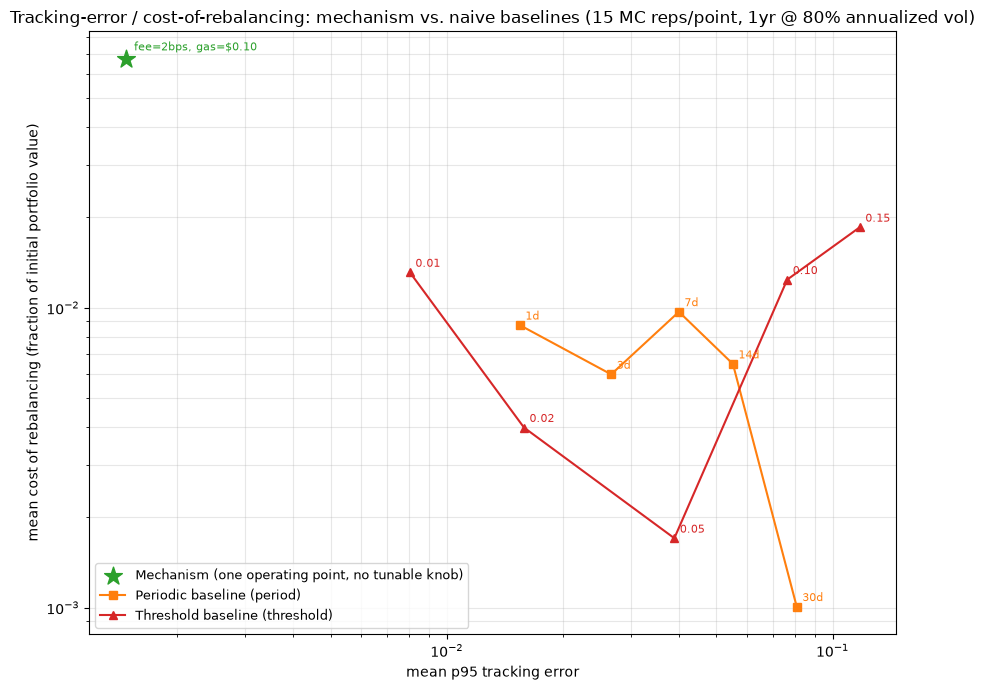

In [6]:
fig, ax = plt.subplots(figsize=(9, 7))

ax.scatter([mech_te], [mech_cost], color="tab:green", s=180, zorder=5, marker="*", label="Mechanism (one operating point, no tunable knob)")
ax.annotate(f"fee=2bps, gas=${ARB_CONFIG.gas_cost_b:.2f}", (mech_te, mech_cost), fontsize=8, color="tab:green", xytext=(6, 6), textcoords="offset points")

periodic_sorted = sorted(periodic_points, key=lambda p: p[2])
ax.plot([p[2] for p in periodic_sorted], [p[1] for p in periodic_sorted], "s-", color="tab:orange", label="Periodic baseline (period)")
for days, cost, te in periodic_points:
    ax.annotate(f"{days}d", (te, cost), fontsize=8, color="tab:orange", xytext=(4, 4), textcoords="offset points")

threshold_sorted = sorted(threshold_points, key=lambda p: p[2])
ax.plot([p[2] for p in threshold_sorted], [p[1] for p in threshold_sorted], "^-", color="tab:red", label="Threshold baseline (threshold)")
for thr, cost, te in threshold_points:
    ax.annotate(f"{thr:.2f}", (te, cost), fontsize=8, color="tab:red", xytext=(4, 4), textcoords="offset points")

ax.set_xlabel("mean p95 tracking error")
ax.set_ylabel("mean cost of rebalancing (fraction of initial portfolio value)")
ax.set_title(f"Tracking-error / cost-of-rebalancing: mechanism vs. naive baselines ({N_MC_REPS} MC reps/point, 1yr @ {SIGMA_ANNUAL:.0%} annualized vol)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend(loc="lower left", fontsize=9)
ax.grid(alpha=0.3, which="both")

plt.tight_layout()
plt.show()

## Summary

**Result:** the mechanism has by far the tightest tracking of anything tested — no baseline setting gets within 2x its tracking error. But it doesn't win on cost: this simulation's "cost" is value lost against a frictionless reference (an LVR-style metric, not raw fee accounting — see `metrics.py`), and continuously quoting a firm price has a real, structural cost on that metric that a scheduled or threshold-triggered rebalancer doesn't pay in the same way. Checked directly in code (§4), not eyeballed: **0 of 10** baseline settings are beaten on both cost and tracking at once (see the printed count above — this number is recorded as found, not asserted toward a target, and has moved as bugs got fixed and assumptions got corrected earlier in this project; treat it as a real, current measurement, not a fixed headline claim to defend).

**What the five notebooks establish, end to end:**
1. The pricing formula is correctly implemented and can't be drained by round-tripping (01).
2. Background noise doesn't break it (02).
3. Self-interested traders actually pull the portfolio back toward target, on real gas-cost economics, no hand-picked dead-zone or cooldown (03).
4. Two manual alternatives were built fairly (04).
5. Across many market histories, the mechanism trades cost for tracking tightness — it doesn't dominate the alternatives outright (this notebook).

**What this does NOT establish:**
- Synthetic (GBM) price data, one volatility level — not historical, and real markets have patterns (crashes, correlated moves, thin liquidity) a random walk doesn't capture.
- An idealized, always-present, always-rational arbitrageur — real correction could be slower/thinner (gas, competition, latency), which would worsen both metrics.
- A gas cost based on current observed Base transaction costs, not measured from the finished contract's actual gas usage.
- A single token pair — multi-token group routing isn't simulated or built yet.
- Python, not the deployed Solidity contract and its real fixed-point rounding (checked separately via Forge).

**What would actually prove this in the real world:** a live testnet deployment (next milestone) running real swap transactions, then real mainnet usage with real capital and traders. This simulation's job is narrower — show the idea is sound enough to justify building the real thing, and produce honest numbers about the actual trade-off (tighter tracking, at a real cost) rather than an overstated claim.